# **LCPB 25-25: REPORT ON DNNs - CODING PART**

Group 2601

* Andreacchio Pasquale 2196577
* Calcagni Matteo Renato 2196575
* Gonzati Agostina 2188428
* Lavarda Nicola 2198664

In [11]:
# "Data handling and visualization" libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# "Modeling" libraries
import torch 
import torch.nn as nn 
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import scipy.special

# "Evaluation and hyperparameter optimization" libraries
import optuna
from sklearn.metrics import classification_report, confusion_matrix

## **Network structure**

In [12]:
# Global paths to dataset and model storage
DATA_PATH = 'data.csv'
MODEL_DB_PATH = 'cancer_study.db'

# Loss function for binary classification (logistic regression)
CRITERION = nn.BCEWithLogitsLoss()

In [13]:
# --- DATASET CLASS ---
class CancerDataset(Dataset):
    def __init__(self, X, y):
        self.samples = torch.tensor(X, dtype=torch.float32)
        self.labels = torch.tensor(y, dtype=torch.float32).view(-1, 1)
    def __len__(self): return len(self.labels)
    def __getitem__(self, index): return self.samples[index], self.labels[index]


# --- DEEP CLASSIFICATION NETWORK - PYTORCH ---
class OptimizedCancerNet(nn.Module):
    def __init__(self, input_size, p_drop):         
        super(OptimizedCancerNet, self).__init__()
        self.net = nn.Sequential(
            # First layer
            nn.Linear(input_size, 16),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.Dropout(p_drop),
            # Second layer
            nn.Linear(16, 8),
            nn.BatchNorm1d(8),
            nn.ReLU(),
            nn.Dropout(p_drop),
            # Third layer
            nn.Linear(8, 4),
            nn.BatchNorm1d(4),
            nn.ReLU(),
            nn.Dropout(p_drop),
            # Output layer
            nn.Linear(4, 1)
            )
    def forward(self, x): return self.net(x)

## **Point 1**

In [14]:
###########################################################################
#                              KEY FUNCTIONS 
###########################################################################

# --- Preprocessing ---
def data_load_clean(data_file):
    data = pd.read_csv(data_file) 
    # Map categories to numbers
    # Benign (B) = 0, Malignant (M) = 1
    data['diagnosis'] = data['diagnosis'].map({'B': 0, 'M': 1.0})
    
    return data

# --- Function to train the model with early stopping ---
def train_model(model, num_epochs, train_loader, test_loader, optimizer, criterion, patience=30, verbose=True, save_path=None):
    if verbose:
        print(f"--- Training started (Max Epochs: {num_epochs}, Patience: {patience}) ---")
        
    best_val_loss = float('inf')
    patience_counter = 0
    history = {'train_loss': [], 'val_loss': []}

    for epoch in range(num_epochs):
        # Training the model
        model.train()
        train_loss = 0.0
        for s, l in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(s), l)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        avg_train_loss = train_loss / len(train_loader)

        # Validate the model on the validation set
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for s, l in test_loader:
                val_loss += criterion(model(s), l).item()
        avg_val_loss = val_loss / len(test_loader)

        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)

        # Early stopping check
        if avg_val_loss < best_val_loss:
            # Model is improving, save the best loss and reset patience counter
            best_val_loss = avg_val_loss
            patience_counter = 0  
            if save_path:
                torch.save(model.state_dict(), save_path)
        else:
            patience_counter += 1 # Model is not improving, increment patience counter

        if verbose and (epoch + 1) % 10 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")

        # Patience check to stop training if no improvement
        if patience_counter >= patience:
            if verbose:
                print(f"Triggered early stopping at epoch {epoch+1}!")
                print(f"Best Validation Loss: {best_val_loss:.4f}")
            break
            
    return best_val_loss, history


# --- Function to be optimized using optuna ---
def objective(trial):
    
    # Parameters to optimize
    drop = trial.suggest_float("dropout_rate", 0.0, 0.5, step=0.1)
    lr = trial.suggest_float("lr", 1e-6, 1e-1, log=True)

    num_feat = len(features)
    model = OptimizedCancerNet(input_size=num_feat, p_drop=drop)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    best_val_loss, history = train_model(model, num_epochs=150, train_loader=train_loader_opt, test_loader=val_loader_opt, 
                                         optimizer=optimizer, criterion=CRITERION, verbose=False)

    test_loss = 0.0
    model.eval() 
    
    with torch.no_grad():
        for s, l in test_loader_opt:
            batch_loss = CRITERION(model(s), l)
            test_loss += batch_loss.item() 
            
    avg_test_loss = test_loss / len(test_loader_opt)
    return avg_test_loss

def find_best_par(objective, path=MODEL_DB_PATH):
    storage_name = f"sqlite:///{path}"
    
    if os.path.isfile(path):
        print("removing previous study db...")
        os.remove(path)
    else:
        print("creating new study db...")

    study = optuna.create_study(
        direction="minimize", 
        study_name="cancer_model_tuning", 
        storage=storage_name,
        load_if_exists=True 
    )

    study.optimize(objective, n_trials=40)
    return study.best_params



###########################################################################
#                              MAIN EXECUTION 
###########################################################################

if __name__ == "__main__":
    
    # Load and preprocess the data
    df = data_load_clean(DATA_PATH)

    # Define features and target
    features = df.columns[2:-1].tolist()
    target = 'diagnosis'

    X = df[features].values
    y = df[target].values

    # --- 1. Data split for hyperparameter tuning (Training, Validation, Test) ---
    # 60% train, 20% validation, 20% test
    X_train_val, X_test_opt, y_train_val, y_test_opt = train_test_split(X, y, test_size=0.2, random_state=42)
    X_train_opt, X_val_opt, y_train_opt, y_val_opt = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=42)
    
    scaler_opt = StandardScaler()
    X_train_opt = scaler_opt.fit_transform(X_train_opt)
    X_val_opt = scaler_opt.transform(X_val_opt)
    X_test_opt = scaler_opt.transform(X_test_opt)

    train_set_opt = CancerDataset(X_train_opt, y_train_opt)
    val_set_opt = CancerDataset(X_val_opt, y_val_opt)
    test_set_opt = CancerDataset(X_test_opt, y_test_opt)

    train_loader_opt = DataLoader(train_set_opt, batch_size=32, shuffle=True)
    val_loader_opt = DataLoader(val_set_opt, batch_size=32, shuffle=False)
    test_loader_opt = DataLoader(test_set_opt, batch_size=32, shuffle=False)

    # --- 2. Data split for final best model evaluation (Training and Test only) ---
    # 80% train, 20% test
    test_size = 0.2
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42)
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # Create and load datasets
    train_set = CancerDataset(X_train, y_train)
    test_set = CancerDataset(X_test, y_test)
    train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
    test_loader = DataLoader(test_set, batch_size=32, shuffle=False)

    # Best hyperparameters search using optuna
    opt = input("Do you want to perform hyperparameter tuning with optuna? (y/n): ").strip().lower()
    if opt == 'y':
        best_parameters = find_best_par(objective, path=MODEL_DB_PATH)
        print(f"\nBest hyperparameters found: {best_parameters}\n")
    else:
        db = optuna.storages.RDBStorage(url=f"sqlite:///{MODEL_DB_PATH}")
        study = optuna.load_study(study_name="cancer_model_tuning", storage=db)
        best_parameters = study.best_params
        print(f"\nBest hyperparameters loaded from previous study: {best_parameters}\n")

    # Sets the definitive parameters 
    p_drop, learning_rate = best_parameters['dropout_rate'], best_parameters['lr'] 

    # Defines the definitive model
    model = OptimizedCancerNet(len(features), p_drop)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    # Model training and saving best weights
    best_val_loss, history = train_model(model=model, num_epochs=250, train_loader=train_loader, 
                                         test_loader=test_loader, optimizer=optimizer, criterion=CRITERION, patience=50, verbose=True, save_path='best_model.pth')

    # Load best model weights for evaluation
    if os.path.exists('best_model.pth'):
        model.load_state_dict(torch.load('best_model.pth'))

    # Save learning curve plot
    plt.figure(figsize=(10, 6))
    plt.plot(history['train_loss'], label='Train Loss', color='#4C72B0', linewidth=2)
    plt.plot(history['val_loss'], label='Validation Loss', color='#C44E52', linewidth=2)
    plt.title('Model Learning Curves (Train vs Validation Loss)', fontsize=16, fontweight='bold')
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Loss (BCEWithLogitsLoss)', fontsize=12)
    plt.legend(loc='upper right', fontsize=11)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.savefig('learning_curve.png', dpi=300)
    plt.close()

    # Model evaluation
    model.eval()
    
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for s, l in test_loader:
            preds = model(s)
            all_preds.append(preds.cpu())
            all_labels.append(l.cpu())

    all_preds_np = torch.cat(all_preds).numpy()
    all_labels_np = torch.cat(all_labels).numpy()

    # Metrics calculation
    threshold = 0.5
    probs = scipy.special.expit(all_preds_np)  # Convert logits to probabilities
    metrics = classification_report(all_labels_np, (probs > threshold).astype(int), output_dict=True)

    # Results presentation as a bar chart
    report_df = pd.DataFrame(metrics).transpose()
    df_plot = report_df.loc[['0.0', '1.0'], ['precision', 'recall', 'f1-score']]

    # Blue = Benign (0), Red = Malignant (1)
    ax = df_plot.T.plot(kind='bar', figsize=(10, 6), color=['#4C72B0', '#C44E52'], edgecolor='black')

    # Aesthetics
    plt.title('Performance Metrics by Class (Breast Cancer)', fontsize=16, fontweight='bold')
    plt.xlabel('Metrics', fontsize=12)
    plt.ylabel('Score', fontsize=12)
    plt.xticks(rotation=0, fontsize=12)

    # Zoom in on the y-axis to better visualize differences in performance
    plt.ylim(0.85, 1.02) 
    plt.legend(['Benign (0)', 'Malignant (1)'], title='Diagnosis', loc='lower right', fontsize=11)

    # Numerical annotations on bars
    for p in ax.patches:
        ax.annotate(f"{p.get_height():.3f}", 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='bottom', fontsize=10, color='black', xytext=(0, 5), 
                    textcoords='offset points')

    plt.tight_layout()
    plt.savefig('classification_report_barchart.png', dpi=300)
    plt.close()

    # Confusion matrix calculation and plot
    cm = confusion_matrix(all_labels_np, (probs > threshold).astype(int))
    plt.figure(figsize=(8, 6))

    # Heatmap with annotations, color scheme, and custom labels
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, 
                xticklabels=['Benign (0)', 'Malignant (1)'], 
                yticklabels=['Benign (0)', 'Malignant (1)'],
                annot_kws={"size": 16, "weight": "bold"})

    # Titles and labels with improved aesthetics
    plt.title('Confusion Matrix', fontsize=16, fontweight='bold', pad=15)
    plt.ylabel('Actual Diagnosis (True)', fontsize=12, fontweight='bold')
    plt.xlabel('Predicted Diagnosis', fontsize=12, fontweight='bold')
    plt.text(0.5, 0.2, 'True Negatives', ha='center', va='center', color='gray', fontsize=9)
    plt.text(1.5, 1.2, 'True Positives', ha='center', va='center', color='white', fontsize=9)

    plt.tight_layout()
    plt.savefig('confusion_matrix.png', dpi=300)
    plt.close()

Do you want to perform hyperparameter tuning with optuna? (y/n):  n



Best hyperparameters loaded from previous study: {'dropout_rate': 0.5, 'lr': 0.010205256935994797}

--- Training started (Max Epochs: 250, Patience: 50) ---
Epoch [10/250], Train Loss: 0.3640, Val Loss: 0.1536
Epoch [20/250], Train Loss: 0.2972, Val Loss: 0.1214
Epoch [30/250], Train Loss: 0.3430, Val Loss: 0.0960
Epoch [40/250], Train Loss: 0.3153, Val Loss: 0.1189
Epoch [50/250], Train Loss: 0.2732, Val Loss: 0.0943
Epoch [60/250], Train Loss: 0.3008, Val Loss: 0.1074
Epoch [70/250], Train Loss: 0.2881, Val Loss: 0.0994
Triggered early stopping at epoch 79!
Best Validation Loss: 0.0941


## **Point 2**

Train: 341  |  Val: 114  |  Test: 114
Input features: 30
Best params from Point 1: {'dropout_rate': 0.5, 'lr': 0.010205256935994797}
Using: dropout=0.5, lr=0.010205

=== Part 2a — Data Reduction ===
  5%  N=  17  F1=0.9212 +- 0.0429  ValLoss=0.2615 +- 0.0297
  10%  N=  34  F1=0.9234 +- 0.0819  ValLoss=0.3337 +- 0.0529
  20%  N=  68  F1=0.9651 +- 0.0180  ValLoss=0.2165 +- 0.0031
  35%  N= 119  F1=0.9748 +- 0.0044  ValLoss=0.0991 +- 0.0107
  50%  N= 170  F1=0.9712 +- 0.0159  ValLoss=0.1154 +- 0.0163
  70%  N= 238  F1=0.9582 +- 0.0190  ValLoss=0.1110 +- 0.0031
  100%  N= 341  F1=0.9716 +- 0.0077  ValLoss=0.1016 +- 0.0094

=== Part 2b — Data Augmentation ===
  x1  N=  341  F1=0.9716 +- 0.0075  ValLoss=0.0974 +- 0.0078
  x2  N=  682  F1=0.9750 +- 0.0157  ValLoss=0.0865 +- 0.0090
  x3  N= 1023  F1=0.9841 +- 0.0091  ValLoss=0.1073 +- 0.0283
  x5  N= 1705  F1=0.9717 +- 0.0133  ValLoss=0.0939 +- 0.0206

=== 2a — Reduction summary ===
 fraction  n_samples  f1_mean  f1_std  val_loss_mean  val_los

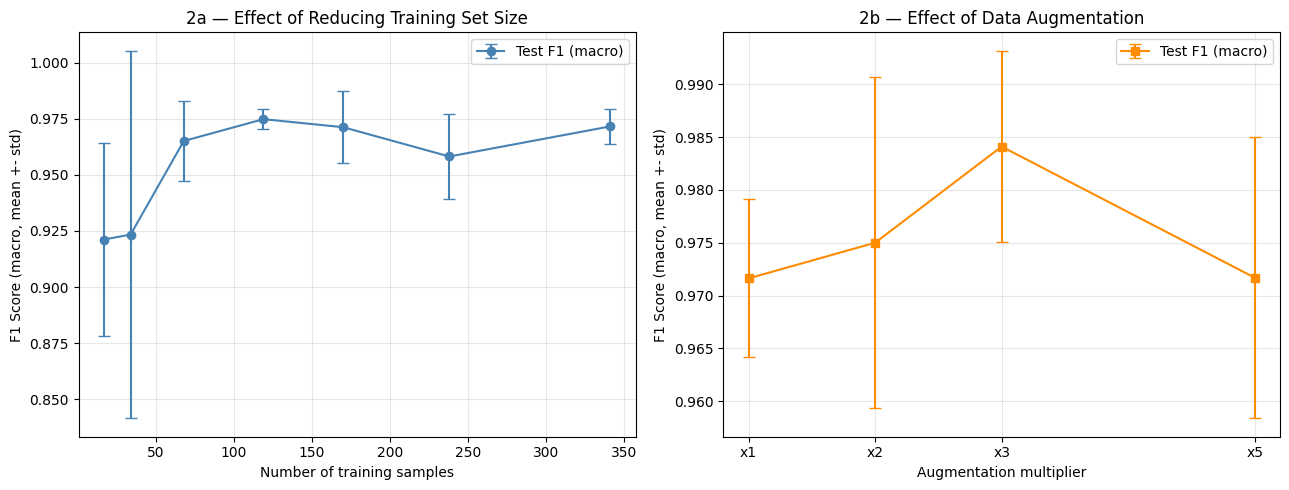

Plot saved to augmentation_f1.png


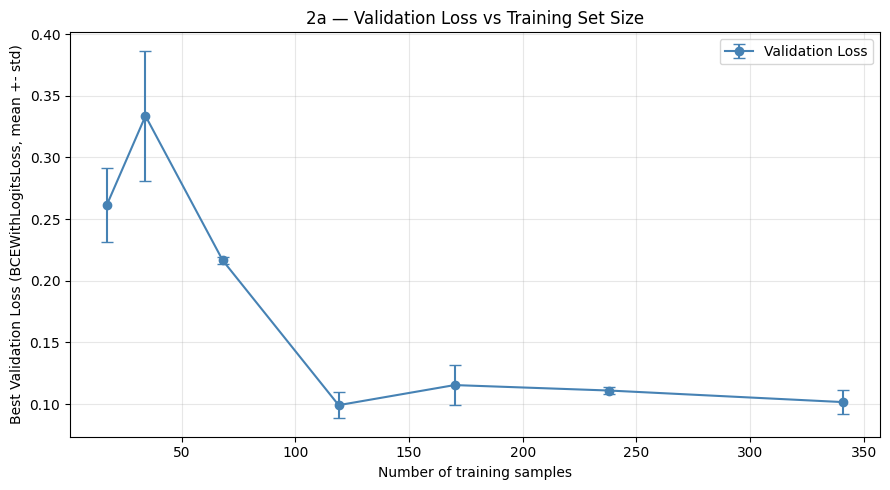

Plot saved to val_loss_reduction.png


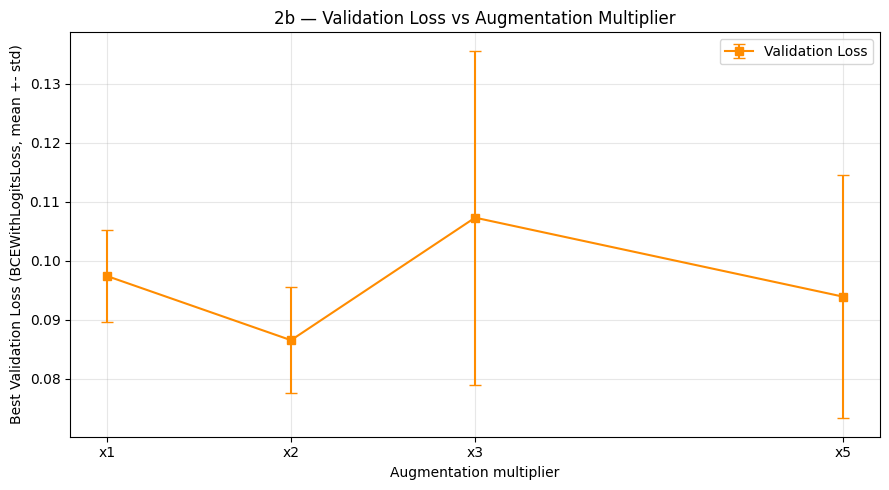

Plot saved to val_loss_augmentation.png


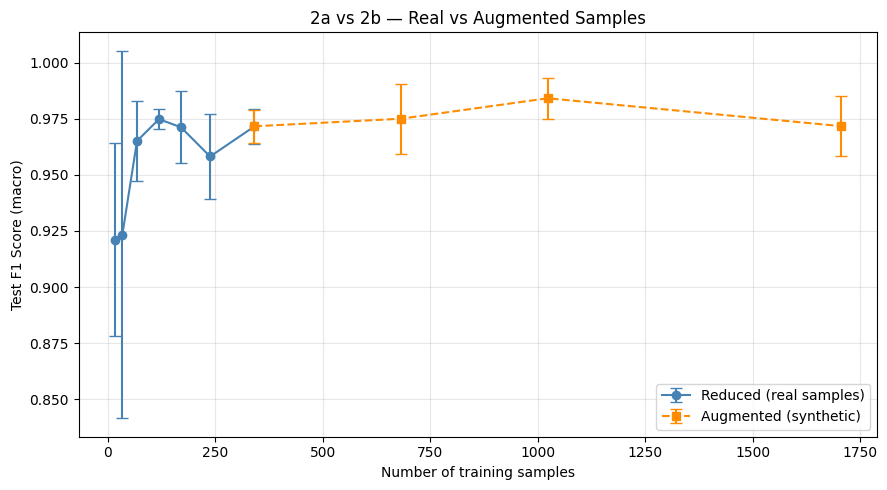

Plot saved to real_vs_augmented.png


In [15]:
"""
exercise1_augmentation.py — Exercise 1, Point 2: Data Augmentation
Implements 2a (data reduction) and 2b (Gaussian noise augmentation)
using the best model found in Point 1 (report_fcnn.py).

Imports model, dataset and training utilities directly from report_fcnn.py.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import copy
import scipy.special
import optuna

from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, classification_report

'''
# Import groupmate's utilities from Point 1
from report_fcnn import (
    data_load_clean,
    CancerDataset,
    OptimizedGPANet,
    train_model,
    DATA_PATH,
    MODEL_DB_PATH,
    CRITERION
)
'''

SEED      = 42
N_REPEATS = 3   # repeat each experiment N times and average


# -----------------------------------------------------------------------
# HELPER: load best hyperparameters from Point 1 SQLite study
# -----------------------------------------------------------------------

def load_best_params(db_path=MODEL_DB_PATH):
    """Load best hyperparameters found by Optuna in Point 1."""
    storage = optuna.storages.RDBStorage(url=f"sqlite:///{db_path}")
    study   = optuna.load_study(study_name="cancer_model_tuning", storage=storage)
    print(f"Best params from Point 1: {study.best_params}")
    return study.best_params


# -----------------------------------------------------------------------
# HELPER: build and train a fresh model, return F1 on test set
# -----------------------------------------------------------------------

def build_and_evaluate(X_tr, y_tr, X_val, y_val, X_te, y_te,
                        p_drop, lr, input_size,
                        num_epochs=150, patience=15):
    """
    Train a fresh OptimizedGPANet with given hyperparameters.
    Returns (f1_macro, best_val_loss).
    Uses BCEWithLogitsLoss + sigmoid threshold=0.5 for binary classification.
    """
    def make_loader(X, y, shuffle=False):
        ds = TensorDataset(
            torch.tensor(X, dtype=torch.float32),
            torch.tensor(y, dtype=torch.float32).view(-1, 1)
        )
        return DataLoader(ds, batch_size=32, shuffle=shuffle)

    tr_loader  = make_loader(X_tr,  y_tr,  shuffle=True)
    val_loader = make_loader(X_val, y_val)
    te_loader  = make_loader(X_te,  y_te)

    model     = OptimizedCancerNet(input_size=input_size, p_drop=p_drop)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

 # train_model returns (best_val_loss, history) — unpack tuple
    best_val_loss, _ = train_model(model, num_epochs=num_epochs,
                                   train_loader=tr_loader, test_loader=val_loader,
                                   optimizer=optimizer, criterion=CRITERION,
                                   patience=patience, verbose=False)

    # Evaluate F1 on test set
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for s, l in te_loader:
            probs = scipy.special.expit(model(s).numpy())
            all_preds.extend((probs > 0.5).astype(int).flatten())
            all_labels.extend(l.numpy().flatten().astype(int))

    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return f1, best_val_loss


# -----------------------------------------------------------------------
# PART 2a — Effect of Reducing Training Set Size
# -----------------------------------------------------------------------

def run_reduction(X_train, y_train, X_val, y_val, X_test, y_test,
                  p_drop, lr, input_size):
    """
    Train the best model on progressively smaller fractions of the training set.
    Repeats each fraction N_REPEATS times and averages.
    """
    fractions = [0.05, 0.10, 0.20, 0.35, 0.50, 0.70, 1.00]
    results   = []

    print("\n=== Part 2a — Data Reduction ===")
    for frac in fractions:
        f1s, val_losses = [], []
        n_samples = int(frac * len(X_train))

        for rep in range(N_REPEATS):
            if frac < 1.0:
                X_tr, _, y_tr, _ = train_test_split(
                    X_train, y_train,
                    train_size=frac,
                    random_state=SEED + rep,
                    stratify=y_train
                )
            else:
                X_tr, y_tr = X_train, y_train

            f1, val_loss = build_and_evaluate(
                X_tr, y_tr, X_val, y_val, X_test, y_test,
                p_drop, lr, input_size
            )
            f1s.append(f1)
            val_losses.append(val_loss)

        results.append({
            'fraction': frac,
            'n_samples': n_samples,
            'f1_mean':       np.mean(f1s),
            'f1_std':        np.std(f1s),
            'val_loss_mean': np.mean(val_losses),
            'val_loss_std':  np.std(val_losses),
        })
        print(f"  {frac:.0%}  N={n_samples:4d}  "
              f"F1={np.mean(f1s):.4f} +- {np.std(f1s):.4f}  "
              f"ValLoss={np.mean(val_losses):.4f} +- {np.std(val_losses):.4f}")

    return pd.DataFrame(results)


# -----------------------------------------------------------------------
# PART 2b — Data Augmentation with Gaussian Noise
# -----------------------------------------------------------------------

def augment_samples(X_tr, y_tr, multiplier, noise_std=0.05, seed=SEED):
    """
    Generate (multiplier-1)*N synthetic samples by adding Gaussian noise
    to randomly selected real training samples.
    noise_std=0.05 is small relative to StandardScaler unit variance.
    Both classes augmented proportionally — class ratio preserved.
    Returns: augmented X and y (originals + synthetics), shuffled.
    """
    rng = np.random.default_rng(seed)
    N   = len(X_tr)
    n_s = (multiplier - 1) * N
    idx = rng.integers(0, N, size=n_s)
    noise     = rng.normal(0, noise_std, size=(n_s, X_tr.shape[1]))
    X_aug = np.vstack([X_tr, X_tr[idx] + noise])
    y_aug = np.concatenate([y_tr, y_tr[idx]])
    perm  = rng.permutation(len(X_aug))
    return X_aug[perm], y_aug[perm]


def run_augmentation(X_train, y_train, X_val, y_val, X_test, y_test,
                     p_drop, lr, input_size):
    """
    Train the best model with augmented training sets.
    Multipliers: x1 (baseline), x2, x3, x5.
    Repeats each N_REPEATS times and averages.
    """
    multipliers = [1, 2, 3, 5]
    results     = []

    print("\n=== Part 2b — Data Augmentation ===")
    for mult in multipliers:
        f1s, val_losses, ns = [], [], []

        for rep in range(N_REPEATS):
            if mult == 1:
                X_tr_aug, y_tr_aug = X_train, y_train
            else:
                X_tr_aug, y_tr_aug = augment_samples(
                    X_train, y_train, mult, seed=SEED + rep
                )
            ns.append(len(X_tr_aug))

            f1, val_loss = build_and_evaluate(
                X_tr_aug, y_tr_aug, X_val, y_val, X_test, y_test,
                p_drop, lr, input_size
            )
            f1s.append(f1)
            val_losses.append(val_loss)

        results.append({
            'multiplier':    mult,
            'n_train':       int(np.mean(ns)),
            'f1_mean':       np.mean(f1s),
            'f1_std':        np.std(f1s),
            'val_loss_mean': np.mean(val_losses),
            'val_loss_std':  np.std(val_losses),
        })
        print(f"  x{mult}  N={int(np.mean(ns)):5d}  "
              f"F1={np.mean(f1s):.4f} +- {np.std(f1s):.4f}  "
              f"ValLoss={np.mean(val_losses):.4f} +- {np.std(val_losses):.4f}")

    return pd.DataFrame(results)


# -----------------------------------------------------------------------
# PLOTTING
# -----------------------------------------------------------------------

def plot_results(red_df, aug_df):
    """Generate and save all plots for 2a and 2b."""

    # --- Figure 1: F1 score (2a and 2b side by side) ---
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    ax = axes[0]
    ax.errorbar(red_df['n_samples'], red_df['f1_mean'], yerr=red_df['f1_std'],
                marker='o', capsize=4, color='steelblue', label='Test F1 (macro)')
    ax.set_xlabel('Number of training samples')
    ax.set_ylabel('F1 Score (macro, mean +- std)')
    ax.set_title('2a — Effect of Reducing Training Set Size')
    ax.legend(); ax.grid(True, alpha=0.3)

    ax2 = axes[1]
    ax2.errorbar(aug_df['multiplier'], aug_df['f1_mean'], yerr=aug_df['f1_std'],
                 marker='s', capsize=4, color='darkorange', label='Test F1 (macro)')
    ax2.set_xlabel('Augmentation multiplier')
    ax2.set_ylabel('F1 Score (macro, mean +- std)')
    ax2.set_title('2b — Effect of Data Augmentation')
    ax2.set_xticks(aug_df['multiplier'])
    ax2.set_xticklabels([f'x{m}' for m in aug_df['multiplier']])
    ax2.legend(); ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('augmentation_f1.png', dpi=120, bbox_inches='tight')
    plt.show()
    print("Plot saved to augmentation_f1.png")

    # --- Figure 2: Validation loss vs training set size (2a) ---
    fig2, ax3 = plt.subplots(figsize=(9, 5))
    ax3.errorbar(red_df['n_samples'], red_df['val_loss_mean'], yerr=red_df['val_loss_std'],
                 marker='o', capsize=4, color='steelblue', label='Validation Loss')
    ax3.set_xlabel('Number of training samples')
    ax3.set_ylabel('Best Validation Loss (BCEWithLogitsLoss, mean +- std)')
    ax3.set_title('2a — Validation Loss vs Training Set Size')
    ax3.legend(); ax3.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('val_loss_reduction.png', dpi=120, bbox_inches='tight')
    plt.show()
    print("Plot saved to val_loss_reduction.png")

    # --- Figure 3: Validation loss vs augmentation multiplier (2b) ---
    fig3, ax4 = plt.subplots(figsize=(9, 5))
    ax4.errorbar(aug_df['multiplier'], aug_df['val_loss_mean'], yerr=aug_df['val_loss_std'],
                 marker='s', capsize=4, color='darkorange', label='Validation Loss')
    ax4.set_xlabel('Augmentation multiplier')
    ax4.set_ylabel('Best Validation Loss (BCEWithLogitsLoss, mean +- std)')
    ax4.set_title('2b — Validation Loss vs Augmentation Multiplier')
    ax4.set_xticks(aug_df['multiplier'])
    ax4.set_xticklabels([f'x{m}' for m in aug_df['multiplier']])
    ax4.legend(); ax4.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('val_loss_augmentation.png', dpi=120, bbox_inches='tight')
    plt.show()
    print("Plot saved to val_loss_augmentation.png")

    # --- Figure 4: Real vs Augmented (F1 comparison) ---
    fig4, ax5 = plt.subplots(figsize=(9, 5))
    ax5.errorbar(red_df['n_samples'], red_df['f1_mean'], yerr=red_df['f1_std'],
                 marker='o', capsize=4, color='steelblue', label='Reduced (real samples)')
    ax5.errorbar(aug_df['n_train'], aug_df['f1_mean'], yerr=aug_df['f1_std'],
                 marker='s', capsize=4, color='darkorange', linestyle='--',
                 label='Augmented (synthetic)')
    ax5.set_xlabel('Number of training samples')
    ax5.set_ylabel('Test F1 Score (macro)')
    ax5.set_title('2a vs 2b — Real vs Augmented Samples')
    ax5.legend(); ax5.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('real_vs_augmented.png', dpi=120, bbox_inches='tight')
    plt.show()
    print("Plot saved to real_vs_augmented.png")


# -----------------------------------------------------------------------
# MAIN
# -----------------------------------------------------------------------

if __name__ == "__main__":

    # --- Load data (same preprocessing as report_fcnn.py) ---
    df       = data_load_clean(DATA_PATH)
    features = df.columns[2:-1].tolist()
    target   = 'diagnosis'

    X = df[features].values
    y = df[target].values

    input_size = len(features)

    # --- Train / val / test split (stratified) ---
    # 60% train, 20% val, 20% test
    X_trainval, X_test, y_trainval, y_test = train_test_split(
        X, y, test_size=0.20, random_state=SEED, stratify=y
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_trainval, y_trainval, test_size=0.25, random_state=SEED, stratify=y_trainval
    )

    # Scale features (fit on training only)
    scaler  = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val   = scaler.transform(X_val)
    X_test  = scaler.transform(X_test)

    print(f"Train: {len(X_train)}  |  Val: {len(X_val)}  |  Test: {len(X_test)}")
    print(f"Input features: {input_size}")

    # --- Load best hyperparameters from Point 1 ---
    best_params = load_best_params(MODEL_DB_PATH)
    p_drop      = best_params['dropout_rate']
    lr          = best_params['lr']
    print(f"Using: dropout={p_drop}, lr={lr:.6f}")

    # --- Run experiments ---
    red_df = run_reduction(X_train, y_train, X_val, y_val, X_test, y_test,
                           p_drop, lr, input_size)

    aug_df = run_augmentation(X_train, y_train, X_val, y_val, X_test, y_test,
                              p_drop, lr, input_size)

    # --- Summary tables ---
    print("\n=== 2a — Reduction summary ===")
    print(red_df.round(4).to_string(index=False))

    print("\n=== 2b — Augmentation summary ===")
    print(aug_df.round(4).to_string(index=False))

    # --- Plots ---
    plot_results(red_df, aug_df)
